In [1]:
from sklearn.datasets import fetch_california_housing
california_housing = fetch_california_housing(as_frame=True)
# print(housing.DESCR)
housing = california_housing.frame[['MedInc', 'HouseAge', 'AveRooms']]
housing['Target'] = california_housing.target
housing.head()

,MedInc,HouseAge,AveRooms,Target
0,8.3252,41.0,6.984127,4.526
1,8.3014,21.0,6.238137,3.585
2,7.2574,52.0,8.288136,3.521
3,5.6431,52.0,5.817352,3.413
4,3.8462,52.0,6.281853,3.422


In [2]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
xtrain, xtest, ytrain, ytest = train_test_split(
    housing[['MedInc', 'HouseAge', 'AveRooms']],
    housing['Target'],
    test_size = 0.2,
    random_state = 42,
)

print(len(xtrain), len(xtest))

16512 4128


In [3]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(xtrain, ytrain)
print(model.coef_, model.intercept_)
prediction = model.predict(xtest)
for i in range(10):
    print(f'real {ytest.array[i]}, predicted {prediction[i]}')

[ 0.4447578   0.01683623 -0.02814968] 0.017295645283375016
real 0.477, predicted 1.0679191240970713
real 0.458, predicted 1.5063409546234627
real 5.00001, predicted 2.3286256242953574
real 2.186, predicted 2.681849548222601
real 2.78, predicted 2.091824371031814
real 1.587, predicted 2.1684024697662174
real 1.982, predicted 2.709364728199375
real 1.575, predicted 2.1588825601055386
real 3.4, predicted 2.1106013001299377
real 4.466, predicted 4.189691798622925


In [4]:
import sklearn.metrics as sm
print(sm.r2_score(ytest, prediction))

0.49717158850807075


In [5]:
import matplotlib.pyplot as plt

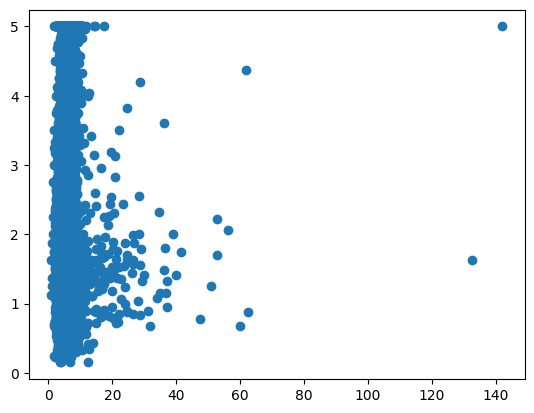

In [6]:
fig, ax = plt.subplots()
ax.scatter(housing['AveRooms'], housing['Target'])
plt.show()

In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()

In [9]:
scaled_housing = scaler.fit_transform(housing[['MedInc', 'HouseAge', 'AveRooms']])

In [10]:
print(scaled_housing[:5])

[[ 2.34476576  0.98214266  0.62855945]
 [ 2.33223796 -0.60701891  0.32704136]
 [ 1.7826994   1.85618152  1.15562047]
 [ 0.93296751  1.85618152  0.15696608]
 [-0.012881    1.85618152  0.3447108 ]]


In [11]:
xtrain2, xtest2, ytrain2, ytest2 = train_test_split(
    scaled_housing,
    housing['Target'],
    test_size = 0.2,
    random_state = 42
)
model2 = LinearRegression()
model2.fit(xtrain2, ytrain2)
print(model2.coef_, model2.intercept_)

[ 0.84494006  0.21188821 -0.06964549] 2.068163168785327


In [12]:
prediction2 = model2.predict(xtest2)
for i in range(10):
    print(f'real {ytest2.array[i]}, predicted {prediction2[i]}')

real 0.477, predicted 1.0679191240970716
real 0.458, predicted 1.5063409546234632
real 5.00001, predicted 2.328625624295359
real 2.186, predicted 2.6818495482226
real 2.78, predicted 2.0918243710318145
real 1.587, predicted 2.1684024697662165
real 1.982, predicted 2.709364728199375
real 1.575, predicted 2.158882560105539
real 3.4, predicted 2.1106013001299364
real 4.466, predicted 4.189691798622924


In [13]:
print(sm.r2_score(ytest2, prediction2))

0.49717158850807075


In [14]:
from IPython.display import Markdown as md

In [15]:
md("|Model|Scale|R^2|\n|-|-|-|\n|LinearRegression|No|%f|\n|LinearRegression|Standard Scaled|%f|\n|" %(
    sm.r2_score(ytest, prediction),
    sm.r2_score(ytest2, prediction2)
))

|Model|Scale|R^2|
|-|-|-|
|LinearRegression|No|0.497172|
|LinearRegression|Standard Scaled|0.497172|
|

# Task 3
Застосуйте різні методи попередньої обробки даних:
Додайте в DataFrame штучну категоріальну ознаку, наприклад:

import numpy as np 
df['Category'] = np.where(df['HouseAge'] > 30, 'Old', 'New')

Перетворіть цю ознаку:
за допомогою factorize;
за допомогою OneHotEncoder.
Додайте штучні пропуски в 1 колонку (наприклад, MedInc), заповніть їх через SimpleImputer (середнім значенням).
Навчіть модель лінійної регресії та порівняйте R² для різних способів кодування категоріальної ознаки.

In [16]:
import numpy as np
housing['Category'] = np.where(housing['HouseAge'] > 30, 'Old', 'New')
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category
0,8.3252,41.0,6.984127,4.526,Old
1,8.3014,21.0,6.238137,3.585,New
2,7.2574,52.0,8.288136,3.521,Old
3,5.6431,52.0,5.817352,3.413,Old
4,3.8462,52.0,6.281853,3.422,Old


In [17]:
import pandas as pd
housing['Factorize'] = pd.factorize(housing['Category'])[0]
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category,Factorize
0,8.3252,41.0,6.984127,4.526,Old,0
1,8.3014,21.0,6.238137,3.585,New,1
2,7.2574,52.0,8.288136,3.521,Old,0
3,5.6431,52.0,5.817352,3.413,Old,0
4,3.8462,52.0,6.281853,3.422,Old,0


In [18]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False, drop="first")
housing['Encoded'] = encoder.fit_transform(housing[['Category']])
housing.head()

,MedInc,HouseAge,AveRooms,Target,Category,Factorize,Encoded
0,8.3252,41.0,6.984127,4.526,Old,0,1.0
1,8.3014,21.0,6.238137,3.585,New,1,0.0
2,7.2574,52.0,8.288136,3.521,Old,0,1.0
3,5.6431,52.0,5.817352,3.413,Old,0,1.0
4,3.8462,52.0,6.281853,3.422,Old,0,1.0


In [19]:
indices = [10, 20, 30, 40, 50]
old_values = housing.loc[indices, 'MedInc']
print(old_values)
housing.loc[indices, 'MedInc'] = None
print(housing.loc[indices, 'MedInc'])

10    3.2031
20    1.3578
30    1.9274
40    2.0978
50    0.9218
Name: MedInc, dtype: float64
10   NaN
20   NaN
30   NaN
40   NaN
50   NaN
Name: MedInc, dtype: float64


In [20]:
from sklearn.impute import SimpleImputer

In [21]:
imputer = SimpleImputer(strategy="mean")
imputed_data = imputer.fit_transform(housing[['MedInc']])

In [22]:
print('Data was filled did not change:', *(f'{a[0]} -- {b}' for a, b in zip(imputed_data[:5], housing['MedInc'][:5])), sep='\n')
print('The gaps are filled in accordance with the strategy - average values:', imputed_data[indices])
housing.head()

Data was filled did not change:
8.3252 -- 8.3252
8.3014 -- 8.3014
7.2574 -- 7.2574
5.6431 -- 5.6431
3.8462 -- 3.8462
The gaps are filled in accordance with the strategy - average values: [[3.87114813]
 [3.87114813]
 [3.87114813]
 [3.87114813]
 [3.87114813]]


,MedInc,HouseAge,AveRooms,Target,Category,Factorize,Encoded
0,8.3252,41.0,6.984127,4.526,Old,0,1.0
1,8.3014,21.0,6.238137,3.585,New,1,0.0
2,7.2574,52.0,8.288136,3.521,Old,0,1.0
3,5.6431,52.0,5.817352,3.413,Old,0,1.0
4,3.8462,52.0,6.281853,3.422,Old,0,1.0


In [24]:
housing_clean = housing.dropna(subset=["MedInc", "HouseAge", "AveRooms", "Factorize", "Target"])

xtrain_f, xtest_f, ytrain_f, ytest_f = train_test_split(
    housing_clean[["MedInc", "HouseAge", "AveRooms", "Factorize"]],
    housing_clean['Target'],
    test_size = 0.2,
    random_state = 42
)

model_f = LinearRegression()
model_f.fit(xtrain_f, ytrain_f)
print(model_f.coef_, model_f.intercept_)
print(model.coef_, model.intercept_)

[ 0.43864505  0.02294631 -0.02470116  0.17662119] -0.25033089559015975
[ 0.4447578   0.01683623 -0.02814968] 0.017295645283375016


In [25]:
housing_clean_e = housing.dropna(subset=["MedInc", "HouseAge", "AveRooms", "Encoded", "Target"])

xtrain_e, xtest_e, ytrain_e, ytest_e = train_test_split(
    housing_clean_e[["MedInc", "HouseAge", "AveRooms", "Encoded"]],
    housing_clean_e['Target'],
    test_size = 0.2,
    random_state = 42
)

model_e = LinearRegression()
model_e.fit(xtrain_e, ytrain_e)


print(model_e.coef_, model_e.intercept_)

[ 0.43864505  0.02294631 -0.02470116 -0.17662119] -0.07370970279811928


In [26]:
from IPython.display import Markdown as md
md("\n".join(("|Model|R^2|","|-|-|", "|Basic|%f|", "|Factorize|%f|", "|Encoded|%f|")) % (
    sm.r2_score(ytest, prediction),
    sm.r2_score(ytest_f, model_f.predict(xtest_f)), 
    sm.r2_score(ytest_e, model_e.predict(xtest_e)),
))

|Model|R^2|
|-|-|
|Basic|0.497172|
|Factorize|0.516420|
|Encoded|0.516420|

# Task 4
Оцініть модель за допомогою крос-валідації та проаналізуйте перенавчання:
Використовуйте всі числові ознаки датасету California Housing.

* Застосуйте StandardScaler для нормалізації даних.
* Навчіть модель лінійної регресії.
* Оцініть її якість за допомогою cross_val_score (k=5, метрика R²).
* Виведіть середнє значення і стандартне відхилення R².
* Порівняйте результати зі звичайним train/test розбиттям.

In [30]:
all_data = california_housing.frame
all_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [31]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(all_data)
scaled_data[:5]

array([[ 2.34476576,  0.98214266,  0.62855945, -0.15375759, -0.9744286 ,
        -0.04959654,  1.05254828, -1.32783522,  2.12963148],
       [ 2.33223796, -0.60701891,  0.32704136, -0.26333577,  0.86143887,
        -0.09251223,  1.04318455, -1.32284391,  1.31415614],
       [ 1.7826994 ,  1.85618152,  1.15562047, -0.04901636, -0.82077735,
        -0.02584253,  1.03850269, -1.33282653,  1.25869341],
       [ 0.93296751,  1.85618152,  0.15696608, -0.04983292, -0.76602806,
        -0.0503293 ,  1.03850269, -1.33781784,  1.16510007],
       [-0.012881  ,  1.85618152,  0.3447108 , -0.03290586, -0.75984669,
        -0.08561576,  1.03850269, -1.33781784,  1.17289952]])

In [32]:
model_all = LinearRegression()
model_all.fit(scaled_data, california_housing.target)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [36]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model_all, scaled_data, california_housing.target, cv=5, scoring="r2")
scores

array([1., 1., 1., 1., 1.])

In [40]:
print(f'Mean R^2: {scores.mean():.1f}')
print(f'Standard Deviation of R^2: {scores.std():.1f}')

Mean R^2: 1.0
Standard Deviation of R^2: 0.0
